### Explorin

In [44]:
#load data
from FilmStressed.data.curated_data import data_dict as stress_resonators

stress_resonators.pop('Sample N') # not sure what sample N is... but getting rid of it
stress_resonators.keys()

dict_keys(['Sample A', 'Sample B', 'Sample C', 'Sample D', 'Sample E'])

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import lsq_linear

In [118]:



# constants
h_SI = 6.62607015e-34
kB_SI = 1.380649e-23
DEFAULT_F_RES = 5.5e9
T_BASE_POWER = 100.0  # mK


def build_power_df(
    stress_resonators,
    n_min=1,
    n_max=1e8,
    loss_frac_floor=0.15,
    ):
    rows = []

    for sample, chip in stress_resonators.items():
        if not isinstance(chip, dict):
            continue

        stress = chip.get("stress", np.nan)
        stress_err = chip.get("stress_err", np.nan)

        for label, sub in chip.items():
            if not isinstance(sub, dict):
                continue

            required = ["Num_Photon", "Qi_Power", "Qi_Power_err"]
            if not all(k in sub for k in required):
                continue

            n = np.asarray(sub["Num_Photon"], dtype=float)
            Q = np.asarray(sub["Qi_Power"], dtype=float)
            Qerr = np.asarray(sub["Qi_Power_err"], dtype=float)

            if "Freq" in sub and len(sub["Freq"]) > 0:
                f_res = float(np.nanmedian(np.asarray(sub["Freq"], dtype=float)))
            else:
                f_res = DEFAULT_F_RES

            good = (
                np.isfinite(n)
                & np.isfinite(Q)
                & np.isfinite(Qerr)
                & (n >= n_min)
                & (n <= n_max)
                & (Q > 0)
                & (Qerr > 0)
            )

            for ni, qi, qerri in zip(n[good], Q[good], Qerr[good]):
                invQ = 1.0 / qi
                invQ_err_stat = qerri / qi**2
                invQ_err_eff = np.sqrt(
                    invQ_err_stat**2 + (loss_frac_floor * invQ)**2
                )

                rows.append({
                    "sample": sample,
                    "label": label,
                    "res_id": f"{sample}::{label}",
                    "stress": stress,
                    "stress_err": stress_err,
                    "n": ni,
                    "Qi": qi,
                    "Qi_err": qerri,
                    "invQ": invQ,
                    "invQ_err": invQ_err_eff,
                    "f_res": f_res,
                })

    return pd.DataFrame(rows)


def tls_saturation_shape(n, log10_nc, beta=0.5):
    nc = 10.0**log10_nc
    return 1.0 / np.sqrt(1.0 + (np.asarray(n, dtype=float) / nc)**beta)


def tls_tanh_factor(T_mK, f_res):
    T_K = T_mK * 1e-3
    x = h_SI * np.asarray(f_res, dtype=float) / (2 * kB_SI * T_K)
    return np.tanh(np.clip(x, 1e-12, 500))


def fit_tls_power_model_profile(
    df_s,
    beta=0.5,
    log10_nc_grid=np.linspace(-2, 8, 401),
    ):
    """
    Model:
        1/Q_i(n,j) = C_j + A_TLS * tanh(hf/2kT) / sqrt(1 + (n/nc)^beta)

    For each fixed n_c, C_j and A_TLS are solved by bounded linear least squares.
    Then profile over n_c.

    This directly tests whether n_c is constrained by the power sweep.
    """
    y = df_s["invQ"].to_numpy(float)
    err = df_s["invQ_err"].to_numpy(float)
    nphot = df_s["n"].to_numpy(float)
    f_res = df_s["f_res"].to_numpy(float)

    res_ids = sorted(df_s["res_id"].unique())
    res_index = {r: i for i, r in enumerate(res_ids)}

    n_res = len(res_ids)

    profile_rows = []
    best = None

    for log10_nc in log10_nc_grid:
        sat = tls_saturation_shape(nphot, log10_nc, beta=beta)
        th = tls_tanh_factor(T_BASE_POWER, f_res)
        tls_shape = th * sat

        # columns: one baseline C_j per resonator, plus one shared TLS amplitude A_TLS
        X = np.zeros((len(df_s), n_res + 1))

        for row_i, r in enumerate(df_s["res_id"]):
            X[row_i, res_index[r]] = 1.0

        X[:, -1] = tls_shape

        Xw = X / err[:, None]
        yw = y / err

        sol = lsq_linear(
            Xw,
            yw,
            bounds=(0, np.inf),
            method="trf",
        )

        yfit = X @ sol.x
        chi2 = np.sum(((y - yfit) / err)**2)

        row = {
            "log10_nc": log10_nc,
            "nc": 10.0**log10_nc,
            "chi2": chi2,
            "success": sol.success,
            "params": sol.x,
            "yfit": yfit,
        }
        profile_rows.append(row)

        if best is None or chi2 < best["chi2"]:
            best = row

    profile = pd.DataFrame([
        {"log10_nc": r["log10_nc"], "nc": r["nc"], "chi2": r["chi2"]}
        for r in profile_rows
    ])

    chi2_min = profile["chi2"].min()
    profile["delta_chi2"] = profile["chi2"] - chi2_min

    # approximate 1-sigma interval for the profiled parameter log10(nc)
    within_1sigma = profile[profile["delta_chi2"] <= 1.0]

    if len(within_1sigma) > 0:
        log_nc_lo = within_1sigma["log10_nc"].min()
        log_nc_hi = within_1sigma["log10_nc"].max()
    else:
        log_nc_lo = np.nan
        log_nc_hi = np.nan

    k = n_res + 2  # C_j per resonator + A_TLS + log10_nc
    npts = len(y)

    best_params = best["params"]

    return {
        "model": "tls_saturation",
        "success": bool(best["success"]),
        "beta": beta,
        "log10_nc": best["log10_nc"],
        "nc": best["nc"],
        "log10_nc_1sigma": (log_nc_lo, log_nc_hi),
        "nc_1sigma": (10.0**log_nc_lo, 10.0**log_nc_hi),
        "A_TLS": best_params[-1],
        "C_res": dict(zip(res_ids, best_params[:-1])),
        "res_ids": res_ids,
        "yfit": best["yfit"],
        "chi2": best["chi2"],
        "npts": npts,
        "k": k,
        "profile": profile,
        "profile_at_boundary": (
            np.isclose(best["log10_nc"], log10_nc_grid[0])
            or np.isclose(best["log10_nc"], log10_nc_grid[-1])
        ),
    }


def fit_power_sweeps_by_sample(
    stress_resonators,
    beta=0.5,
    log10_nc_grid=np.linspace(-2, 8, 401),
    loss_frac_floor=0.15,
    ):
    power_df = build_power_df(
        stress_resonators,
        loss_frac_floor=loss_frac_floor,
    )

    results = {}
    rows = []

    for sample, df_s in power_df.groupby("sample"):
        if len(df_s) < 5:
            continue

        
        tls = fit_tls_power_model_profile(
            df_s,
            beta=beta,
            log10_nc_grid=log10_nc_grid,
        )


        results[sample] = {
            "data": df_s.copy(),
            "tls_saturation": tls,
        }

        rows.append({
            "sample": sample,
            "stress": df_s["stress"].iloc[0],
            "npts": len(df_s),
            "n_res": df_s["res_id"].nunique(),
            "n_min": df_s["n"].min(),
            "n_max": df_s["n"].max(),
            "nc_best": tls["nc"],
            "nc_1sigma_low": tls["nc_1sigma"][0],
            "nc_1sigma_high": tls["nc_1sigma"][1],
            "A_TLS": tls["A_TLS"],
            "chi2_tls": tls["chi2"],
            "nc_at_boundary": tls["profile_at_boundary"],
        })

    summary = pd.DataFrame(rows).sort_values("stress")
    return power_df, summary, results


power_df, power_summary, power_results = fit_power_sweeps_by_sample(
    stress_resonators,
    beta=0.5,   
    log10_nc_grid=np.linspace(-4, 8, 501),
    loss_frac_floor=0.1,
)

power_summary

,sample,stress,npts,n_res,n_min,n_max,nc_best,nc_1sigma_low,nc_1sigma_high,A_TLS,chi2_tls,nc_at_boundary
0,Sample A,-734.0,60,4,1.11,70900.0,0.000100,0.000100,7.870458,3.881078e-05,16.946425,True
1,Sample B,-535.0,119,6,5.95,2720000.0,13.677288,1.270574,57.543994,5.798858e-07,47.572641,False
2,Sample C,-368.0,64,3,1.08,11300000.0,0.301995,0.089536,0.731139,1.832466e-06,12.913676,False
3,Sample D,-41.0,163,8,1.14,6950000.0,0.356451,0.183654,0.619441,2.653253e-06,121.399198,False
4,Sample E,62.5,61,3,1.84,5630000.0,0.010965,0.000100,0.285759,4.329663e-06,18.448954,False


In [119]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def plot_power_sweep_fits(
    power_results,
    figsize=None,
    cmap_name="magma",
    n_fit_points=2000,
    plot_loss=False,
    savepath=None,
    ):
    samples = sorted(
        power_results.keys(),
        key=lambda s: power_results[s]["data"]["stress"].iloc[0],
    )

    n_samples = len(samples)

    if figsize is None:
        figsize = (10, 3.2 * n_samples)

    fig, axs = plt.subplots(
        n_samples,
        2,
        figsize=figsize,
        squeeze=False,
    )

    cmap = cm.get_cmap(cmap_name)

    for i, sample in enumerate(samples):
        result = power_results[sample]
        df_s = result["data"]
        tls = result["tls_saturation"]

        ax = axs[i, 0]
        axp = axs[i, 1]

        res_groups = list(df_s.groupby("res_id"))
        colors = cmap(np.linspace(0.15, 0.90, len(res_groups)))

        nplot = np.logspace(
            np.log10(df_s["n"].min()),
            np.log10(df_s["n"].max()),
            n_fit_points,
        )

        for color, (res_id, df_r) in zip(colors, res_groups):
            df_r = df_r.sort_values("n")

            Cj = tls["C_res"][res_id]
            A = tls["A_TLS"]
            f_res = df_r["f_res"].median()
            th = tls_tanh_factor(T_BASE_POWER, f_res)

            y_invQ_fit = (
                Cj
                + A
                * th
                * tls_saturation_shape(
                    nplot,
                    np.log10(tls["nc"]),
                    beta=tls["beta"],
                )
            )

            if plot_loss:
                y_data = df_r["invQ"]
                y_err = df_r["invQ_err"]
                y_fit = y_invQ_fit
                ylabel = r"$1/Q_i$"
            else:
                y_data = df_r["Qi"]
                y_err = df_r["Qi_err"]
                y_fit = 1.0 / y_invQ_fit
                ylabel = r"$Q_i$"

            ax.errorbar(
                df_r["n"],
                y_data,
                yerr=y_err,
                fmt="o",
                ms=4.2,
                capsize=2.5,
                color=color,
                ecolor=color,
                elinewidth=1.0,
                markeredgewidth=0.7,
                alpha=0.85,
                label=res_id.split("::")[-1],
                zorder=5,
            )

            ax.plot(
                nplot,
                y_fit,
                "-",
                lw=2.0,
                color=color,
                alpha=0.95,
                zorder=4,
            )

        stress = df_s["stress"].iloc[0]

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"$\langle n\rangle$")
        ax.set_ylabel(ylabel)

        ax.set_title(
            f"{sample}, stress={stress:+.0f} MPa\n",
            fontsize=10,
        )

        ax.grid(True, which="major", alpha=0.25)
        ax.grid(True, which="minor", alpha=0.08)

        ax.legend(
            fontsize=7,
            ncol=2,
            frameon=True,
            handlelength=1.5,
        )

        
        # Profile likelihood 
        
        profile = tls["profile"]

        axp.plot(
            profile["log10_nc"],
            profile["delta_chi2"],
            color="0.1",
            lw=2.2,
        )

        axp.axhline(
            1,
            color="0.45",
            ls="--",
            lw=1.0,
            label=r"$\Delta\chi^2=1$",
        )

        axp.axhline(
            4,
            color="0.65",
            ls=":",
            lw=1.1,
            label=r"$\Delta\chi^2=4$",
        )

        axp.axvline(
            np.log10(tls["nc"]),
            color="#D55E00",
            lw=2.0,
            label=rf"$n_c={tls['nc']:.2g}$",
        )

        axp.set_xlabel(r"$\log_{10}(n_c)$")
        axp.set_ylabel(r"$\Delta\chi^2$")
        axp.set_title("Profile over TLS saturation scale", fontsize=10)
        axp.set_ylim(0, 6)
        axp.grid(alpha=0.25)

        axp.legend(
            fontsize=7.5,
            frameon=True,
            loc="best",
        )

        for a in (ax, axp):
            a.tick_params(
                axis="both",
                labelsize=8.5,
                direction="in",
                top=True,
                right=True,
            )

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

        if savepath.lower().endswith(".png"):
            fig.savefig(savepath[:-4] + ".pdf", bbox_inches="tight")
        elif savepath.lower().endswith(".pdf"):
            fig.savefig(savepath[:-4] + ".png", dpi=300, bbox_inches="tight")

    return fig

/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_66160/1254401111.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


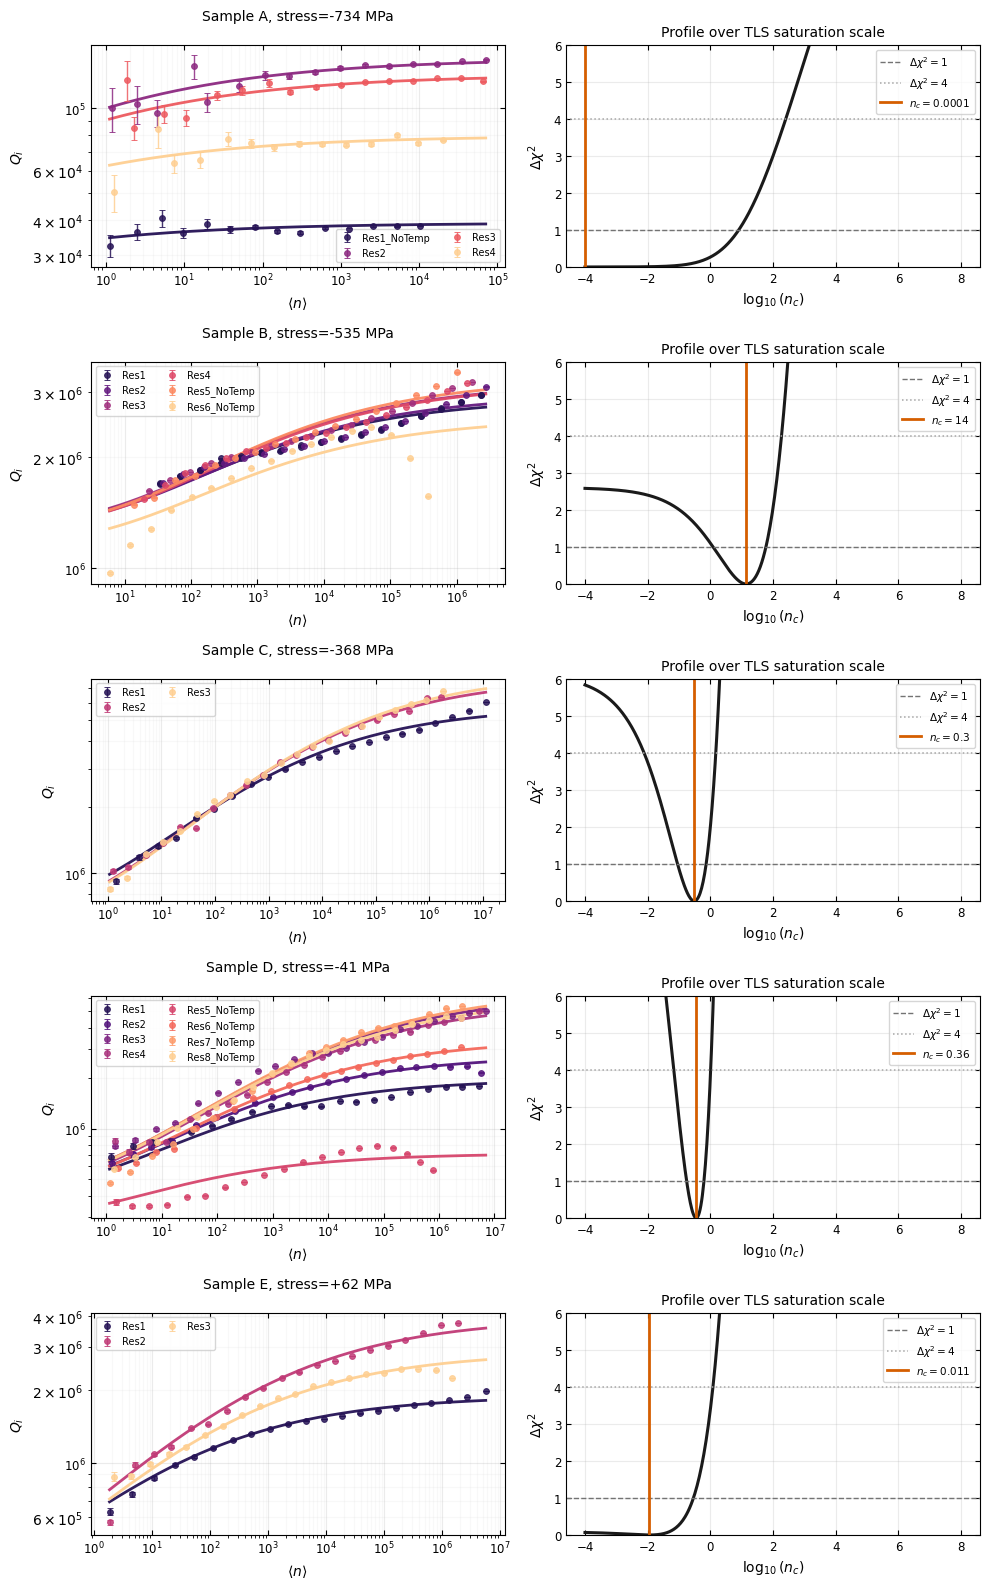

In [120]:
fig = plot_power_sweep_fits(
    power_results,
    cmap_name="magma",
    plot_loss=False,
    savepath="power_sweeps.png",
)



/var/folders/47/4fncnhqn5wq1khr62czfdv4h0000gp/T/ipykernel_66160/1254401111.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


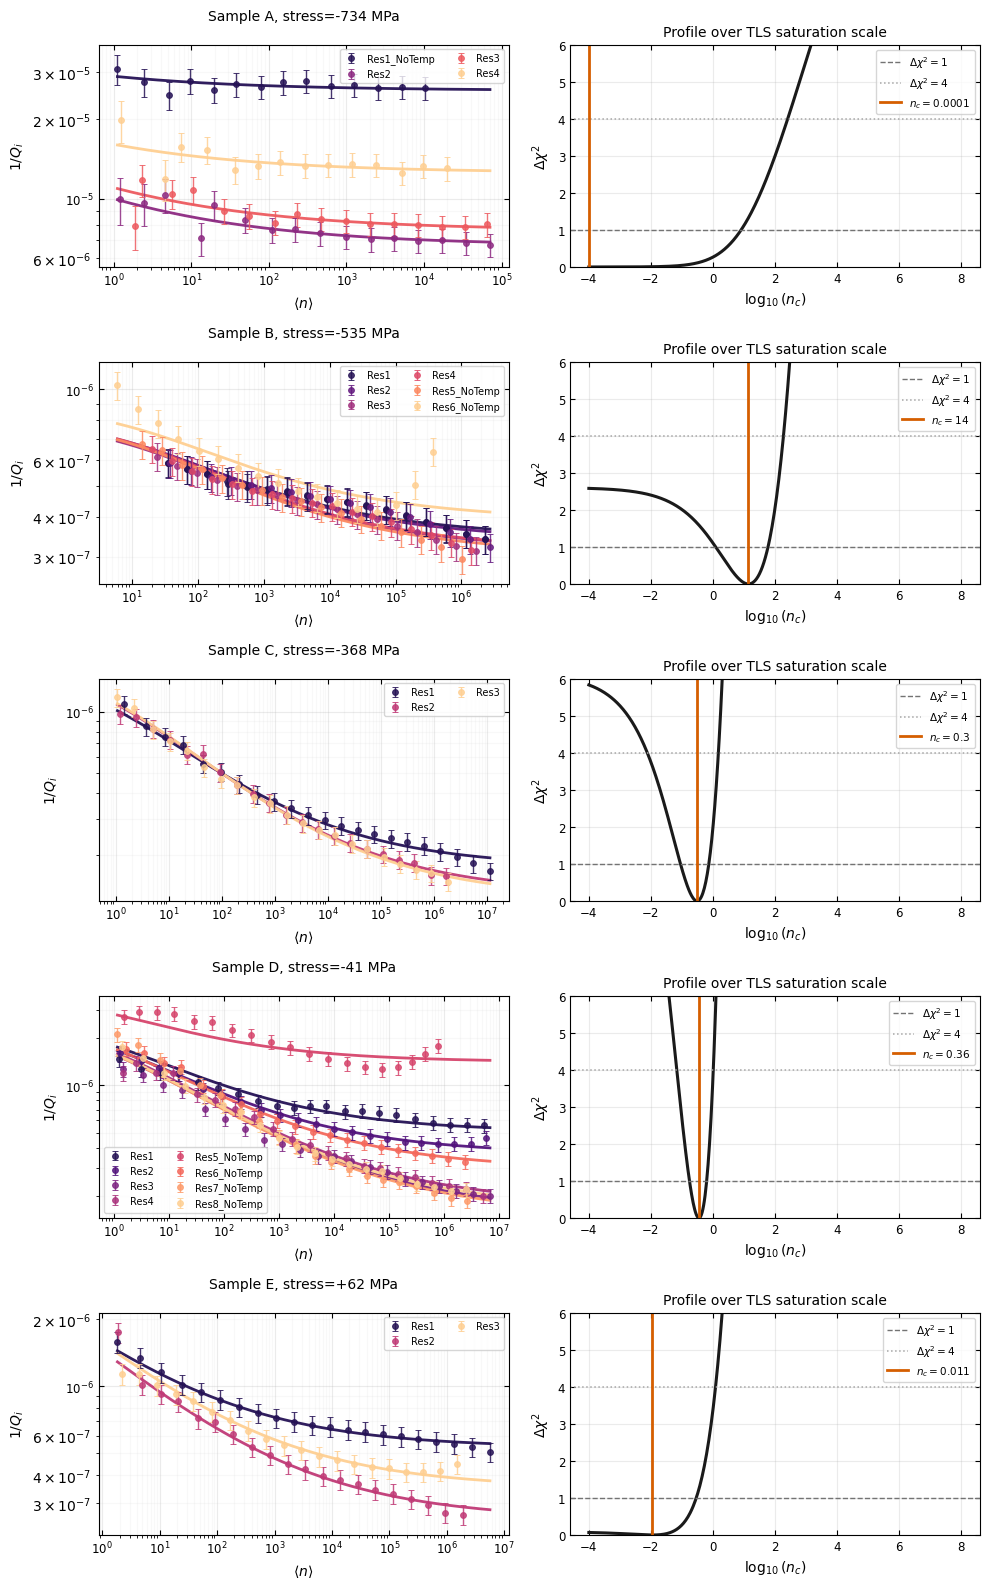

In [121]:
fig = plot_power_sweep_fits(
    power_results,
    cmap_name="magma",
    plot_loss=True,
    savepath="power_sweeps_loss.png",
)



Text(0.5, 0, 'Stress [MPa]')

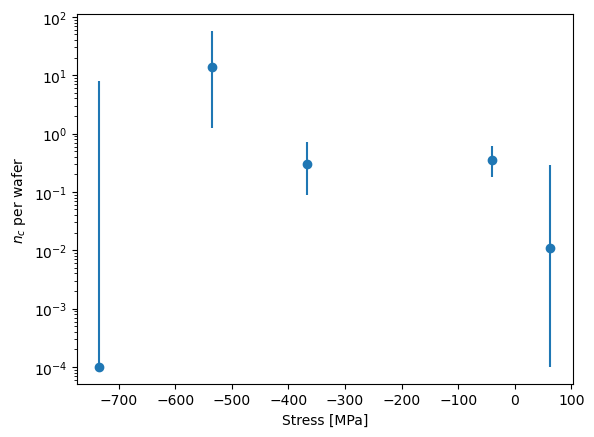

In [124]:
c = power_summary['sample']!='Sample N'
nc = power_summary['nc_best']
plt.errorbar(power_summary['stress'][c],nc[c],
             yerr=(nc[c]-power_summary['nc_1sigma_low'][c],power_summary['nc_1sigma_high'][c]-nc[c]), 
            marker='o', linestyle='none')
plt.yscale('log')

plt.ylabel('$n_c$ per wafer')
plt.xlabel('Stress [MPa]')



In [125]:
power_summary["dof_tls"] = power_summary["npts"] - (power_summary["n_res"] + 2)
power_summary["chi2_red_tls"] = power_summary["chi2_tls"] / power_summary["dof_tls"]
power_summary[["sample", "stress", "chi2_red_tls", "nc_best", "nc_1sigma_low", "nc_1sigma_high"]]

,sample,stress,chi2_red_tls,nc_best,nc_1sigma_low,nc_1sigma_high
0,Sample A,-734.0,0.313823,0.000100,0.000100,7.870458
1,Sample B,-535.0,0.428582,13.677288,1.270574,57.543994
2,Sample C,-368.0,0.218876,0.301995,0.089536,0.731139
3,Sample D,-41.0,0.793459,0.356451,0.183654,0.619441
4,Sample E,62.5,0.329446,0.010965,0.000100,0.285759
